--- Initial Sales Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   TV_Ad_Spend         200 non-null    float64
 1   Radio_Ad_Spend      200 non-null    float64
 2   Newspaper_Ad_Spend  200 non-null    float64
 3   Sales               200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

--- Missing Values Count ---
TV_Ad_Spend           0
Radio_Ad_Spend        0
Newspaper_Ad_Spend    0
Sales                 0
dtype: int64

--- First 5 Dataset Records ---
   TV_Ad_Spend  Radio_Ad_Spend  Newspaper_Ad_Spend      Sales
0   118.616634       33.891424            5.918707  16.295089
1   285.707149        8.786298           36.297010  20.040552
2   222.278243       12.273292           21.199590  18.374555
3   183.610960       45.434938           33.405384  21.140027
4    55.245406       32.289308   

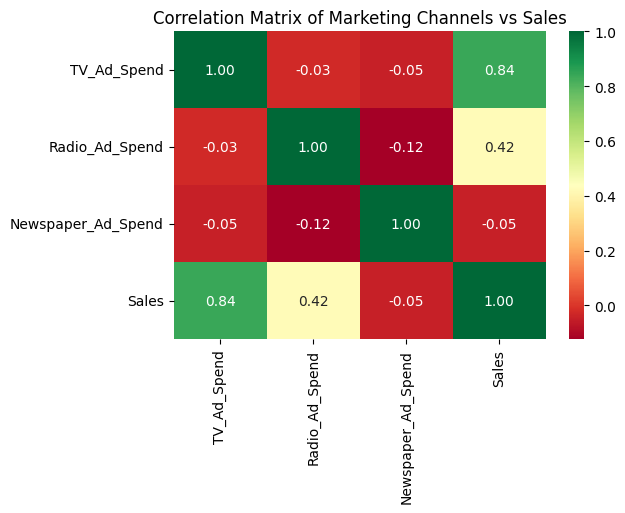


--- Sales Regression Engine Evaluation Summary ---
Mean Absolute Error (MAE): 1.06 units
Root Mean Squared Error (RMSE): 1.25 units
R-squared Score (Model Accuracy Measure): 0.9374 (Max 1.0)


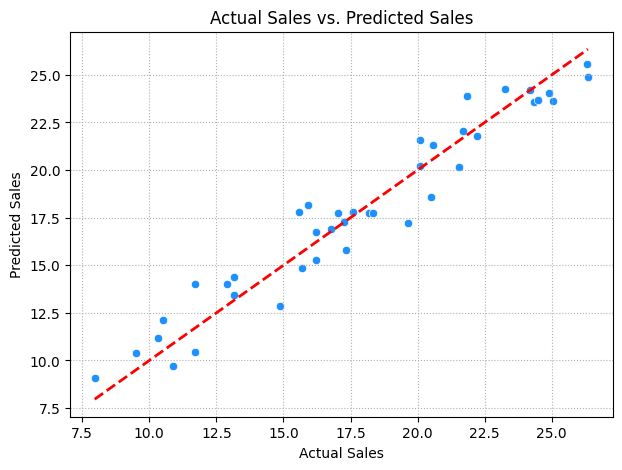

In [1]:
# ==========================================
# CODEALPHA DATA SCIENCE INTERNSHIP
# TASK 4: SALES PREDICTION USING PYTHON
# ==========================================

# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. Generate Simulated Sales Dataset (Reflecting Advertising Spend vs Sales)
# Features: TV, Radio, and Newspaper advertising budget (in thousands)
np.random.seed(42)
dataset_size = 200

tv_spend = np.random.uniform(10.0, 300.0, size=dataset_size)
radio_spend = np.random.uniform(5.0, 50.0, size=dataset_size)
newspaper_spend = np.random.uniform(2.0, 40.0, size=dataset_size)

# Target Sales formula with some random noise: Sales depend heavily on TV and Radio
sales = 5.0 + (0.05 * tv_spend) + (0.18 * radio_spend) + (0.01 * newspaper_spend) + np.random.normal(0, 1.5, size=dataset_size)

mock_sales_data = {
    'TV_Ad_Spend': tv_spend,
    'Radio_Ad_Spend': radio_spend,
    'Newspaper_Ad_Spend': newspaper_spend,
    'Sales': sales
}

df = pd.DataFrame(mock_sales_data)

# 3. Data Preprocessing & Cleaning Verification
print("--- Initial Sales Dataset Information ---")
print(df.info())
print("\n--- Missing Values Count ---")
print(df.isnull().sum())
print("\n--- First 5 Dataset Records ---")
print(df.head())

# 4. Exploratory Data Analysis (EDA) Visualizations
# Chart: Correlation Heatmap to check which ad platform affects sales the most
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Matrix of Marketing Channels vs Sales')
plt.show()

# 5. Feature Selection: Extracting Feature Variables (X) and Target Vector (y)
X = df[['TV_Ad_Spend', 'Radio_Ad_Spend', 'Newspaper_Ad_Spend']]
y = df['Sales']

# 6. Train/Test Split Allocation (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Feature Scaling (Standardizing continuous variables)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 8. Model Instantiation & Training (Linear Regression)
sales_model = LinearRegression()
sales_model.fit(X_train_scaled, y_train)

# 9. Run Predictions and Evaluate Model Accuracy
y_pred = sales_model.predict(X_test_scaled)

# Evaluation Metrics Definitions
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- Sales Regression Engine Evaluation Summary ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} units")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} units")
print(f"R-squared Score (Model Accuracy Measure): {r2:.4f} (Max 1.0)")

# 10. Visualizing Actual vs Predicted Sales
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.title('Actual Sales vs. Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.grid(True, linestyle=':')
plt.show()